# Atelier Préparation de Données Tabulaires

**Contexte** : préparation d'un jeu de données de capteurs IoT issus de bâtiments intelligents
(température, humidité, CO₂, consommation énergétique, occupation...) en vue d'un modèle de
Machine Learning (prédiction de consommation / détection d'anomalies).

Ce notebook suit la structure de l'atelier, **question par question**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")
%matplotlib inline

---
# Partie 1 – Explorer les données

### 1) Charger les données CSV

In [2]:
df = pd.read_csv("../data/smart_building_raw.csv")
df.head()

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
0,1174,2025-02-13 06:00:00,B8,Entrepôt,A,23.0,40.0,851.0,26.0,138.4,Eco,Normal,Jeudi,Non
1,1275,2025-03-10 12:00:00,B7,Bureau,D,28.0,69.0,538.0,0.0,170.2,Eco,Normal,Lundi,Non
2,1493,2025-05-04 00:00:00,B5,Centre commercial,B,19.5,52.3,1198.0,64.0,149.8,Normal,Normal,Dimanche,Oui
3,1073,2025-01-19 00:00:00,B6,Université,D,20.0,58.4,1014.0,30.0,141.6,Normal,Normal,Dimanche,Non
4,1454,2025-04-24 06:00:00,B7,Bureau,D,26.8,70.5,628.0,42.0,228.3,Normal,Normal,Jeudi,Non


### 2) Afficher les premières lignes du dataset

In [3]:
df.head()

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
0,1174,2025-02-13 06:00:00,B8,Entrepôt,A,23.0,40.0,851.0,26.0,138.4,Eco,Normal,Jeudi,Non
1,1275,2025-03-10 12:00:00,B7,Bureau,D,28.0,69.0,538.0,0.0,170.2,Eco,Normal,Lundi,Non
2,1493,2025-05-04 00:00:00,B5,Centre commercial,B,19.5,52.3,1198.0,64.0,149.8,Normal,Normal,Dimanche,Oui
3,1073,2025-01-19 00:00:00,B6,Université,D,20.0,58.4,1014.0,30.0,141.6,Normal,Normal,Dimanche,Non
4,1454,2025-04-24 06:00:00,B7,Bureau,D,26.8,70.5,628.0,42.0,228.3,Normal,Normal,Jeudi,Non


### 3) Afficher les dernières lignes du dataset

In [4]:
df.tail()

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
502,1107,2025-01-27 12:00:00,B2,École,C,29.8,66.5,778.0,48.0,243.5,Normal,Normal,Lundi,Non
503,1271,2025-03-09 12:00:00,B3,Hôpital,B,21.1,66.3,3900.0,53.0,145.8,Eco,Alerte,Dimanche,Oui
504,1349,2025-03-29 00:00:00,B5,Centre commercial,B,21.6,61.9,959.0,33.0,100.2,Eco,Normal,Samedi,Non
505,1436,2025-04-19 18:00:00,B7,Bureau,C,21.2,54.5,1066.0,38.0,150.9,Boost,Normal,Samedi,Oui
506,1103,2025-01-26 12:00:00,B2,École,D,NaN,64.8,584.0,29.0,163.4,Normal,Panne,Dimanche,Non


### 4) Combien d'observations contient le dataset ?

In [5]:
n_obs = df.shape[0]
print(f"Le dataset contient {n_obs} observations (lignes).")

Le dataset contient 507 observations (lignes).


### 5) Combien de variables possède le dataset ?

In [6]:
n_var = df.shape[1]
print(f"Le dataset possède {n_var} variables (colonnes).")
df.columns.tolist()

Le dataset possède 14 variables (colonnes).


['id_mesure',
 'date',
 'batiment',
 'type_batiment',
 'zone',
 'temperature',
 'humidite',
 'co2',
 'occupation',
 'consommation_kwh',
 'mode_climatisation',
 'etat_systeme',
 'jour_semaine',
 'alerte']

### 6) Identifier les variables numériques

On utilise `select_dtypes` pour repérer les colonnes de type numérique.
`id_mesure` est numérique au sens du type mais c'est en réalité un **identifiant**
(cf. question 9), on l'exclut donc des variables numériques "utiles".

In [7]:
variables_numeriques = df.select_dtypes(include=[np.number]).columns.tolist()
print("Variables numériques (type) :", variables_numeriques)

variables_numeriques_utiles = [c for c in variables_numeriques if c != "id_mesure"]
print("Variables numériques utiles (hors identifiant) :", variables_numeriques_utiles)

Variables numériques (type) : ['id_mesure', 'temperature', 'humidite', 'co2', 'occupation', 'consommation_kwh']
Variables numériques utiles (hors identifiant) : ['temperature', 'humidite', 'co2', 'occupation', 'consommation_kwh']


### 7) Identifier les variables catégorielles

Colonnes de type `object` (texte), hors la date qui est une variable temporelle à part.

In [8]:
variables_categorielles = df.select_dtypes(include="object").columns.tolist()
variables_categorielles = [c for c in variables_categorielles if c != "date"]
print("Variables catégorielles :", variables_categorielles)

Variables catégorielles : ['batiment', 'type_batiment', 'zone', 'mode_climatisation', 'etat_systeme', 'jour_semaine', 'alerte']


/var/folders/0h/_d5jczk96_v7v7jl988tw0xm0000gn/T/ipykernel_160/4155203364.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  variables_categorielles = df.select_dtypes(include="object").columns.tolist()


### 8) Identifier les dates

On tente la conversion en `datetime` avec `errors="coerce"` : les dates mal formées ou
impossibles (ex : `2025-02-30`, `2025-13-45`, `"date_invalide"`) sont alors transformées en
`NaT` plutôt que de faire planter le chargement — un problème de qualité supplémentaire à
traiter comme les autres valeurs manquantes.

In [9]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
variables_dates = ["date"]
print("Variable(s) de type date :", variables_dates)

nb_dates_invalides = df["date"].isna().sum()
print(f"{nb_dates_invalides} dates invalides transformées en NaT (valeurs manquantes).")
df["date"].head()

Variable(s) de type date : ['date']
5 dates invalides transformées en NaT (valeurs manquantes).


0   2025-02-13 06:00:00
1   2025-03-10 12:00:00
2   2025-05-04 00:00:00
3   2025-01-19 00:00:00
4   2025-04-24 06:00:00
Name: date, dtype: datetime64[us]

### 9) Identifier les identifiants

`id_mesure` est un identifiant unique de chaque mesure (une ligne = un identifiant).
Il n'a aucune valeur prédictive et doit être exclu des variables explicatives du modèle.

In [10]:
print("id_mesure est-il unique sur toutes les lignes ?", df["id_mesure"].is_unique)
variables_identifiants = ["id_mesure"]
print("Variable(s) identifiant(s) :", variables_identifiants)

id_mesure est-il unique sur toutes les lignes ? False
Variable(s) identifiant(s) : ['id_mesure']


### 10) Statistiques descriptives : moyenne, médiane, min, max, écart-type, quartiles

In [11]:
df[variables_numeriques_utiles].describe().T.assign(
    mediane=df[variables_numeriques_utiles].median()
)[["mean","mediane","std","min","25%","50%","75%","max"]]

,mean,mediane,std,min,25%,50%,75%,max
temperature,24.154141,24.00,7.418465,-30.0,21.600,24.00,26.000,96.0
humidite,57.864113,57.55,16.026336,-12.0,49.275,57.55,65.750,160.0
co2,844.150000,787.50,582.181386,89.0,623.750,787.50,952.000,6000.0
occupation,44.850299,46.00,24.949139,-20.0,27.000,46.00,61.000,116.0
consommation_kwh,169.069323,169.80,53.164294,-100.0,136.875,169.80,202.975,336.2


### 11) Y a-t-il des variables potentiellement problématiques ?

D'après les statistiques ci-dessus, plusieurs variables présentent des valeurs suspectes :

- **temperature** : minimum très bas et maximum très élevé (valeurs physiquement improbables
  pour un bâtiment) ;
- **humidite** : devrait être bornée entre 0 et 100 (%), or on observe des valeurs hors de cet
  intervalle ;
- **co2** : présence de valeurs extrêmement élevées comparées au reste de la distribution ;
- **occupation** : ne peut pas être négative (nombre de personnes) ;
- **consommation_kwh** : ne peut pas être négative ;
- **type_batiment**, **mode_climatisation** : variables catégorielles avec probablement des
  catégories mal orthographiées / mal normalisées (espaces, casse).

On explore ces points en détail dans la suite.

### 12) Données incohérentes

**a) Humidité < 0**

In [12]:
mask_humidite_neg = df["humidite"] < 0
print(f"{mask_humidite_neg.sum()} lignes avec une humidité négative.")
df.loc[mask_humidite_neg, ["id_mesure", "humidite"]]

3 lignes avec une humidité négative.


,id_mesure,humidite
281,1126,-5.0
335,1036,-8.0
366,1216,-12.0


**b) Humidité > 100**

In [13]:
mask_humidite_sup100 = df["humidite"] > 100
print(f"{mask_humidite_sup100.sum()} lignes avec une humidité > 100%.")
df.loc[mask_humidite_sup100, ["id_mesure", "humidite"]]

7 lignes avec une humidité > 100%.


,id_mesure,humidite
59,1246,108.0
103,1016,145.0
128,1156,160.0
160,1186,125.0
268,1276,140.0
327,1066,132.0
342,1096,110.0


**c) Température extrêmement élevée (ou basse) — on fixe un seuil physiquement raisonnable pour un bâtiment (ex : entre -10°C et 45°C)**

In [14]:
mask_temp_aberrante = (df["temperature"] < -10) | (df["temperature"] > 45)
print(f"{mask_temp_aberrante.sum()} lignes avec une température hors de [-10°C, 45°C].")
df.loc[mask_temp_aberrante, ["id_mesure", "temperature"]]

6 lignes avec une température hors de [-10°C, 45°C].


,id_mesure,temperature
7,1141,72.5
116,1181,96.0
161,1061,88.0
185,1221,-25.0
358,1101,-30.0
499,1021,95.2


**d) Occupation négative**

In [15]:
mask_occupation_neg = df["occupation"] < 0
print(f"{mask_occupation_neg.sum()} lignes avec une occupation négative.")
df.loc[mask_occupation_neg, ["id_mesure", "occupation"]]

5 lignes avec une occupation négative.


,id_mesure,occupation
22,1031,-5.0
376,1231,-8.0
430,1081,-12.0
487,1131,-2.0
494,1331,-20.0


**e) Consommation négative**

In [16]:
mask_conso_neg = df["consommation_kwh"] < 0
print(f"{mask_conso_neg.sum()} lignes avec une consommation négative.")
df.loc[mask_conso_neg, ["id_mesure", "consommation_kwh"]]

4 lignes avec une consommation négative.


,id_mesure,consommation_kwh
59,1246,-15.0
154,1046,-50.0
199,1146,-20.0
441,1346,-100.0


In [17]:
df_clean = df.copy()

df_clean.loc[mask_humidite_neg | mask_humidite_sup100, "humidite"] = np.nan
df_clean.loc[mask_temp_aberrante, "temperature"] = np.nan
df_clean.loc[mask_occupation_neg, "occupation"] = np.nan
df_clean.loc[mask_conso_neg, "consommation_kwh"] = np.nan

print("Nombre de valeurs transformées en NaN par cette étape :")
print("humidite     :", (mask_humidite_neg | mask_humidite_sup100).sum())
print("temperature  :", mask_temp_aberrante.sum())
print("occupation   :", mask_occupation_neg.sum())
print("consommation :", mask_conso_neg.sum())

Nombre de valeurs transformées en NaN par cette étape :
humidite     : 10
temperature  : 6
occupation   : 5
consommation : 4


**g) Catégories mal orthographiées**

On regarde les valeurs uniques des variables catégorielles : on y trouve des variantes
d'écriture d'une même catégorie (espaces superflus, majuscules/minuscules différentes,
fautes de frappe comme `"Bureu"` pour `"Bureau"`, `"entrepot"` sans accent pour `"Entrepôt"`,
`"normale"` pour `"Normal"`, etc.).

In [18]:
for c in ["type_batiment", "mode_climatisation", "etat_systeme"]:
    print(f"--- {c} ---")
    print(sorted(df_clean[c].dropna().unique().tolist()))
    print()

--- type_batiment ---
[' Bureau ', ' UNIVERSITÉ', 'BUREAU', 'Bureau', 'Bureu', 'Centre commercial', 'Entrepôt', 'Hôpital', 'Université', 'bureau', 'centre commercial', 'ecole', 'entrepot', 'hôpital ', 'ÉCOLE', 'École']

--- mode_climatisation ---
['BOOST', 'Boost', 'Eco', 'Normal', 'Normal ', 'normal', 'normale']

--- etat_systeme ---
['Alerte', 'Normal', 'Panne']



**h) Normaliser les catégories textuelles : suppression des espaces puis uniformisation de la casse**

In [19]:
for c in ["type_batiment", "mode_climatisation", "etat_systeme", "jour_semaine"]:
    df_clean[c] = df_clean[c].str.strip().str.lower()

# Correction des fautes de frappe / variantes restantes après normalisation de la casse
mapping_type_batiment = {
    "bureau": "bureau",
    "bureu": "bureau",          # faute de frappe
    "université": "universite",
    "universite": "universite",
    "entrepôt": "entrepot",
    "entrepot": "entrepot",
    "hôpital": "hopital",
    "hopital": "hopital",
    "école": "ecole",
    "ecole": "ecole",
    "centre commercial": "centre commercial",
}
mapping_climatisation = {
    "eco": "eco",
    "normal": "normal",
    "normale": "normal",        # faute de frappe
    "boost": "boost",
}

df_clean["type_batiment"] = df_clean["type_batiment"].replace(mapping_type_batiment)
df_clean["mode_climatisation"] = df_clean["mode_climatisation"].replace(mapping_climatisation)

print("type_batiment :", sorted(df_clean["type_batiment"].dropna().unique().tolist()))
print("mode_climatisation :", sorted(df_clean["mode_climatisation"].dropna().unique().tolist()))
print("etat_systeme :", sorted(df_clean["etat_systeme"].dropna().unique().tolist()))
print("jour_semaine :", sorted(df_clean["jour_semaine"].dropna().unique().tolist()))

type_batiment : ['bureau', 'centre commercial', 'ecole', 'entrepot', 'hopital', 'universite']
mode_climatisation : ['boost', 'eco', 'normal']
etat_systeme : ['alerte', 'normal', 'panne']
jour_semaine : ['dimanche', 'jeudi', 'lundi', 'mardi', 'mercredi', 'samedi', 'vendredi']


### 13) Valeurs manquantes

**a) Nombre et pourcentage de valeurs manquantes par colonne**

In [20]:
missing_count = df_clean.isna().sum()
missing_pct = (df_clean.isna().mean() * 100).round(2)
missing_summary = pd.DataFrame({
    "nb_manquantes": missing_count,
    "pct_manquantes": missing_pct
}).sort_values("nb_manquantes", ascending=False)
missing_summary

,nb_manquantes,pct_manquantes
humidite,21,4.14
temperature,18,3.55
occupation,11,2.17
consommation_kwh,9,1.78
co2,7,1.38
date,5,0.99
mode_climatisation,5,0.99
jour_semaine,5,0.99
type_batiment,4,0.79
id_mesure,0,0.00


**b) Quelle variable possède le plus de valeurs manquantes ?**

In [21]:
var_plus_manquante = missing_summary.index[0]
print(f"La variable avec le plus de valeurs manquantes est : '{var_plus_manquante}' "
      f"({missing_summary.iloc[0]['nb_manquantes']:.0f} valeurs, "
      f"{missing_summary.iloc[0]['pct_manquantes']}%).")

La variable avec le plus de valeurs manquantes est : 'humidite' (21 valeurs, 4.14%).


**c) Quelle stratégie utiliser pour les valeurs manquantes ?**

Le taux de valeurs manquantes est faible pour toutes les colonnes concernées (moins de ~5%),
ce qui permet une **imputation** plutôt qu'une suppression massive de lignes :

- variables numériques (temperature, humidite, co2, occupation, consommation_kwh) →
  imputation par la **médiane**, plus robuste aux valeurs extrêmes restantes que la moyenne ;
- variables catégorielles (type_batiment, mode_climatisation, jour_semaine) →
  imputation par le **mode** (valeur la plus fréquente).

C'est exactement la stratégie qui sera formalisée dans le pipeline scikit-learn (Partie 6).

**d) Peut-on supprimer toutes les lignes contenant des valeurs manquantes ?**

Techniquement oui, mais ce n'est pas recommandé ici : cumulées sur toutes les colonnes, les
lignes concernées par au moins une valeur manquante représentent une part non négligeable du
dataset (voir calcul ci-dessous). Supprimer ces lignes ferait perdre de l'information utile et
pourrait biaiser le jeu de données (ex : si les valeurs manquantes ne sont pas réparties au
hasard entre bâtiments ou entre classes de la cible `alerte`).

**e) Dans quels cas utiliser la moyenne ?**
Quand la distribution de la variable est à peu près symétrique et sans valeurs extrêmes
marquées : la moyenne résume alors bien la tendance centrale.

**f) Quand préférer la médiane ?**
Quand la distribution est asymétrique ou contient des valeurs extrêmes (outliers) : la médiane
n'est pas influencée par ces valeurs, contrairement à la moyenne. C'est le cas de nos variables
(co2, consommation_kwh...) qui contiennent des valeurs extrêmes.

**g) Comment traiter une variable catégorielle ?**
On ne peut pas calculer de moyenne/médiane sur du texte : on impute généralement par le
**mode** (catégorie la plus fréquente), ou on crée une catégorie explicite `"Inconnu"` si
l'absence de valeur est elle-même une information potentiellement utile.

In [22]:
lignes_avec_manquant = df_clean.isna().any(axis=1).sum()
print(f"{lignes_avec_manquant} lignes sur {len(df_clean)} "
      f"({lignes_avec_manquant/len(df_clean)*100:.1f}%) contiennent au moins une valeur manquante.")

73 lignes sur 507 (14.4%) contiennent au moins une valeur manquante.


### 14) Doublons

**a) Identifier les doublons**

In [23]:
doublons_mask = df_clean.duplicated(keep=False)
print(f"{df_clean.duplicated().sum()} lignes sont des doublons (en comptant une occurrence par groupe).")
print(f"{doublons_mask.sum()} lignes au total appartiennent à un groupe de doublons.")

7 lignes sont des doublons (en comptant une occurrence par groupe).
14 lignes au total appartiennent à un groupe de doublons.


**b) Afficher les doublons**

In [24]:
df_clean[doublons_mask].sort_values("id_mesure")

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
192,1026,2025-01-07 06:00:00,B6,bureau,A,23.0,74.3,952.0,89.0,247.6,normal,normal,mardi,Oui
117,1026,2025-01-07 06:00:00,B6,bureau,A,23.0,74.3,952.0,89.0,247.6,normal,normal,mardi,Oui
9,1118,2025-01-30 06:00:00,B1,bureau,A,22.0,NaN,479.0,64.0,145.0,normal,normal,jeudi,Non
123,1118,2025-01-30 06:00:00,B1,bureau,A,22.0,NaN,479.0,64.0,145.0,normal,normal,jeudi,Non
23,1264,2025-03-07 18:00:00,B1,bureau,B,21.1,38.3,1034.0,74.0,199.2,normal,panne,vendredi,Oui
434,1264,2025-03-07 18:00:00,B1,bureau,B,21.1,38.3,1034.0,74.0,199.2,normal,panne,vendredi,Oui
455,1320,2025-03-21 18:00:00,B7,bureau,B,27.5,27.2,359.0,33.0,185.8,normal,normal,vendredi,Non
464,1320,2025-03-21 18:00:00,B7,bureau,B,27.5,27.2,359.0,33.0,185.8,normal,normal,vendredi,Non
238,1402,2025-04-11 06:00:00,B2,ecole,A,22.6,44.0,868.0,62.0,172.5,eco,normal,vendredi,Non
418,1402,2025-04-11 06:00:00,B2,ecole,A,22.6,44.0,868.0,62.0,172.5,eco,normal,vendredi,Non


**c) Sont-ils réellement identiques ?**

On compare les doublons en excluant `id_mesure` (qui est par construction unique) pour voir si
le *contenu* des mesures est strictement identique.

In [25]:
cols_hors_id = [c for c in df_clean.columns if c != "id_mesure"]
doublons_contenu = df_clean.duplicated(subset=cols_hors_id, keep=False)
print(f"{doublons_contenu.sum()} lignes ont un contenu strictement identique (hors id_mesure).")
# Comparaison : sont-ils identiques uniquement sur id_mesure (faux doublons) ou sur tout le reste ?
print("Les doublons détectés en (a) le sont-ils aussi hors id_mesure ?",
      (doublons_mask == doublons_contenu).all())

14 lignes ont un contenu strictement identique (hors id_mesure).
Les doublons détectés en (a) le sont-ils aussi hors id_mesure ? True


**d) Supprimer les doublons réellement identifiés**

In [26]:
nb_avant = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=cols_hors_id, keep="first")
nb_apres = len(df_clean)
print(f"{nb_avant - nb_apres} lignes dupliquées supprimées ({nb_avant} -> {nb_apres} lignes).")

7 lignes dupliquées supprimées (507 -> 500 lignes).


**e) Vérifier la suppression**

In [27]:
print("Nombre de doublons restants :", df_clean.duplicated(subset=cols_hors_id).sum())
df_clean = df_clean.reset_index(drop=True)
df_clean.shape

Nombre de doublons restants : 0


(500, 14)

### 15) Température, humidité, CO₂, consommation : distributions, dispersion, valeurs extrêmes

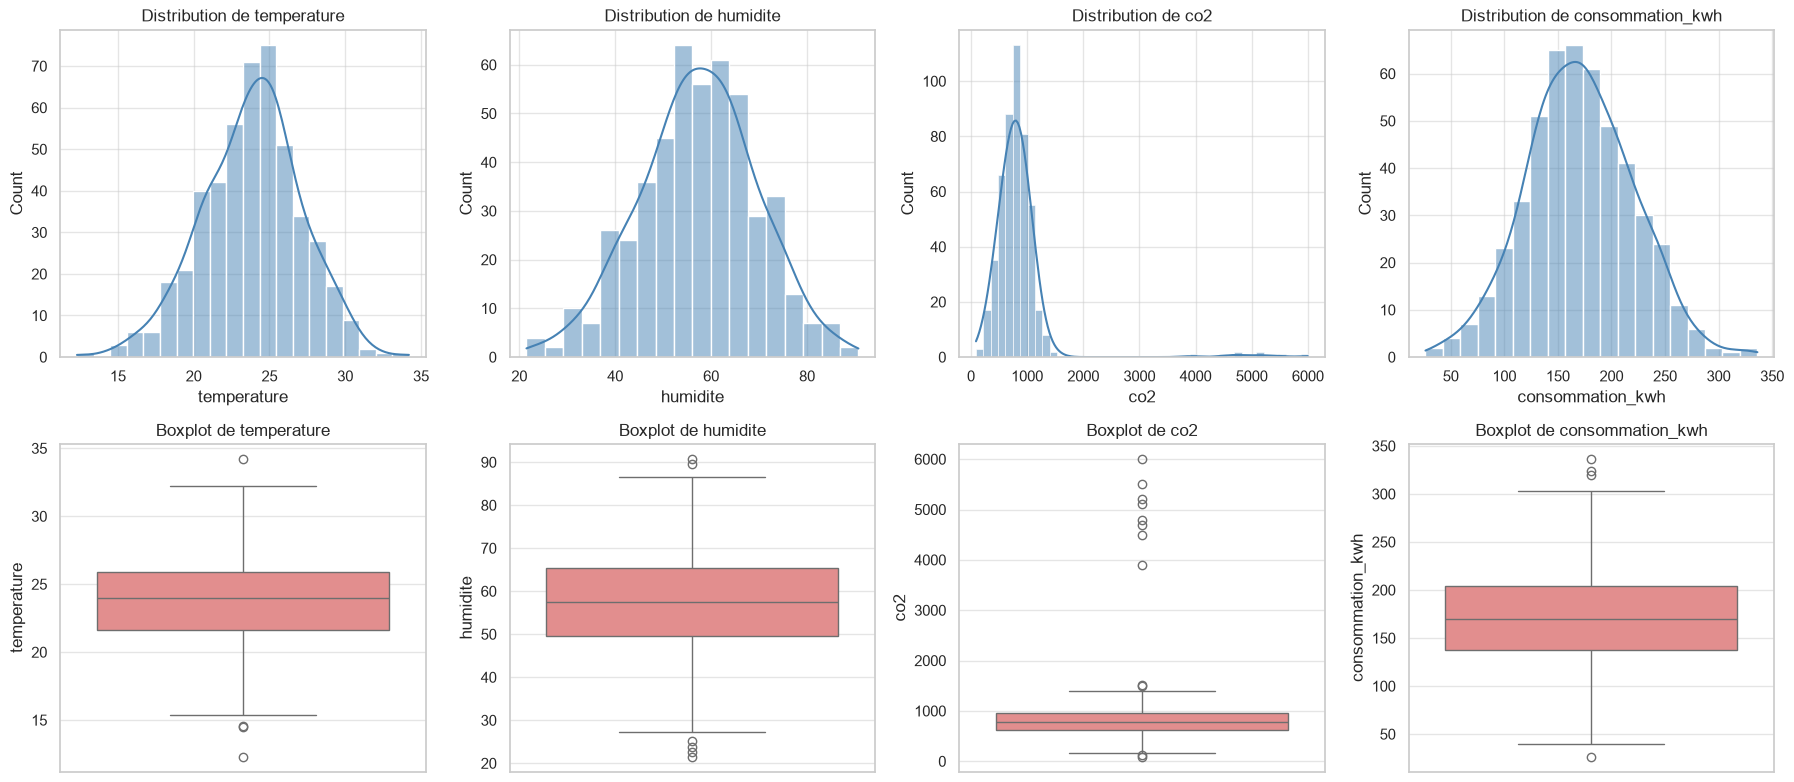

In [28]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
variables_a_visualiser = ["temperature", "humidite", "co2", "consommation_kwh"]

for i, var in enumerate(variables_a_visualiser):
    sns.histplot(df_clean[var].dropna(), kde=True, ax=axes[0, i], color="steelblue")
    axes[0, i].set_title(f"Distribution de {var}")
    sns.boxplot(y=df_clean[var].dropna(), ax=axes[1, i], color="lightcoral")
    axes[1, i].set_title(f"Boxplot de {var}")

plt.tight_layout()
plt.show()

**a) Distributions (symétrique ou non)**
- `temperature` : distribution globalement symétrique, en forme de cloche, centrée autour de
  20-25°C.
- `humidite` : distribution relativement symétrique, légèrement étalée.
- `co2` : distribution asymétrique à droite (étalée vers les fortes valeurs), avec une queue
  de valeurs élevées.
- `consommation_kwh` : distribution plutôt symétrique, en cloche.


**b) Dispersion**
La dispersion (écart-type / IQR) est la plus marquée pour `co2`, ce qui reflète la présence de
quelques valeurs très élevées ; les autres variables ont une dispersion plus resserrée autour
de leur médiane.

**c) Valeurs extrêmes / d) Valeurs potentiellement aberrantes**
Les boxplots font ressortir des points au-delà des moustaches, en particulier sur `co2`
(quelques mesures très supérieures au reste de la distribution) — ce sont des candidats à
un traitement en tant qu'outliers.

### 16) Quelle stratégie utiliser pour les valeurs aberrantes ?

In [29]:
for var in variables_a_visualiser:
    q1, q3 = df_clean[var].quantile([0.25, 0.75])
    iqr = q3 - q1
    borne_inf, borne_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    nb_outliers = ((df_clean[var] < borne_inf) | (df_clean[var] > borne_sup)).sum()
    print(f"{var:18s} bornes IQR = [{borne_inf:.1f}, {borne_sup:.1f}]  -> {nb_outliers} valeurs hors bornes")

temperature        bornes IQR = [15.2, 32.3]  -> 4 valeurs hors bornes
humidite           bornes IQR = [25.8, 89.0]  -> 6 valeurs hors bornes
co2                bornes IQR = [132.0, 1444.0]  -> 12 valeurs hors bornes
consommation_kwh   bornes IQR = [36.6, 305.4]  -> 4 valeurs hors bornes


On détecte ces valeurs aberrantes avec la méthode de l'IQR (règle des 1.5×IQR), une méthode robuste et standard pour des variables numériques continues.

Stratégie retenue :

les valeurs déjà identifiées comme physiquement impossibles (Partie 1.12) ont été mises à NaN puis seront imputées par la médiane ;
pour les outliers restants mais physiquement plausibles (ex : un pic de CO₂ lors d'une forte occupation), on préfère ne pas les supprimer arbitrairement — ils peuvent être des événements réels et informatifs (notamment pour la détection d'anomalies, un des objectifs du projet). On les conserve, en s'appuyant sur StandardScaler/modèles robustes, plutôt que de les écraser ou de perdre ces observations. Un RobustScaler (basé sur médiane/IQR) serait une alternative encore plus prudente si l'on souhaite limiter leur influence sans les supprimer.

### 17) Fréquence des variables catégorielles

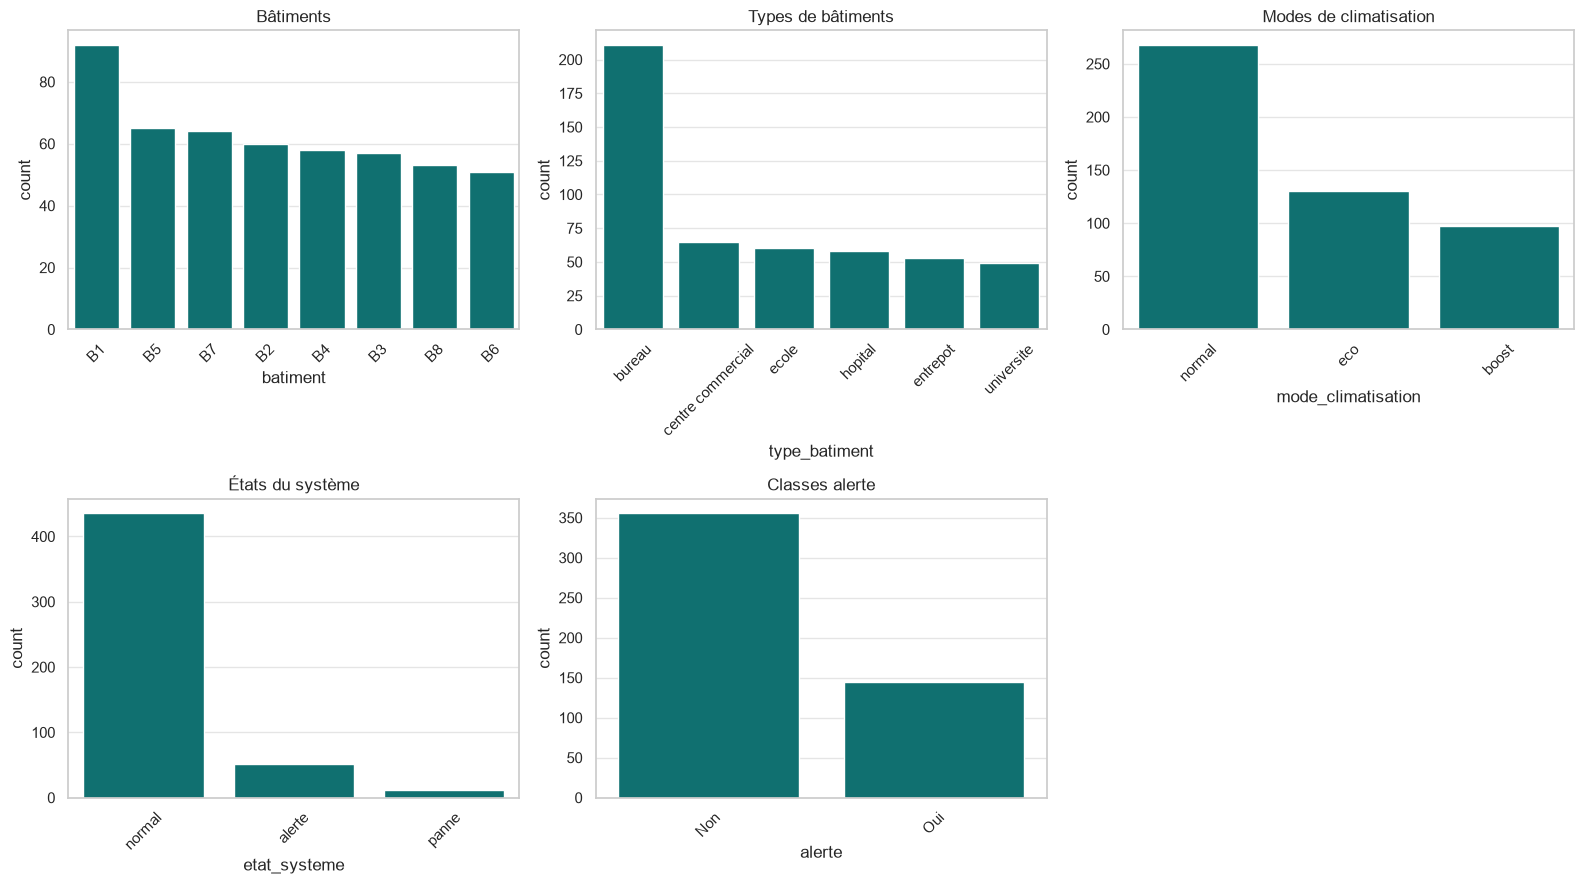

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
freq_vars = [
    ("batiment", "Bâtiments"),
    ("type_batiment", "Types de bâtiments"),
    ("mode_climatisation", "Modes de climatisation"),
    ("etat_systeme", "États du système"),
    ("alerte", "Classes alerte"),
]
for ax, (col, titre) in zip(axes.flat, freq_vars):
    order = df_clean[col].value_counts().index
    sns.countplot(data=df_clean, x=col, order=order, ax=ax, color="teal")
    ax.set_title(titre)
    ax.tick_params(axis='x', rotation=45)
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()

### 18) Y a-t-il un déséquilibre des classes sur la variable « alerte » ?

In [31]:
alerte_counts = df_clean["alerte"].value_counts()
alerte_pct = df_clean["alerte"].value_counts(normalize=True) * 100
print(alerte_counts)
print()
print(alerte_pct.round(1))

alerte
Non    356
Oui    144
Name: count, dtype: int64

alerte
Non    71.2
Oui    28.8
Name: proportion, dtype: float64


Oui, il y a un **déséquilibre modéré des classes** : la classe `"Non"` (pas d'alerte)
représente une majorité nette des observations contre la classe `"Oui"` (alerte). Ce n'est pas
un déséquilibre extrême (on n'est pas à 99%/1%), mais il devra être pris en compte :
- en utilisant `stratify=y` lors du split train/test (Partie 3), pour conserver les mêmes
  proportions dans les deux ensembles ;
- éventuellement, lors de la modélisation future, avec des métriques adaptées (F1-score,
  precision/recall, AUC-ROC) plutôt que la simple accuracy, voire des techniques de
  rééquilibrage (`class_weight="balanced"`, sur/sous-échantillonnage type SMOTE).

### 19) Corrélation entre variables numériques

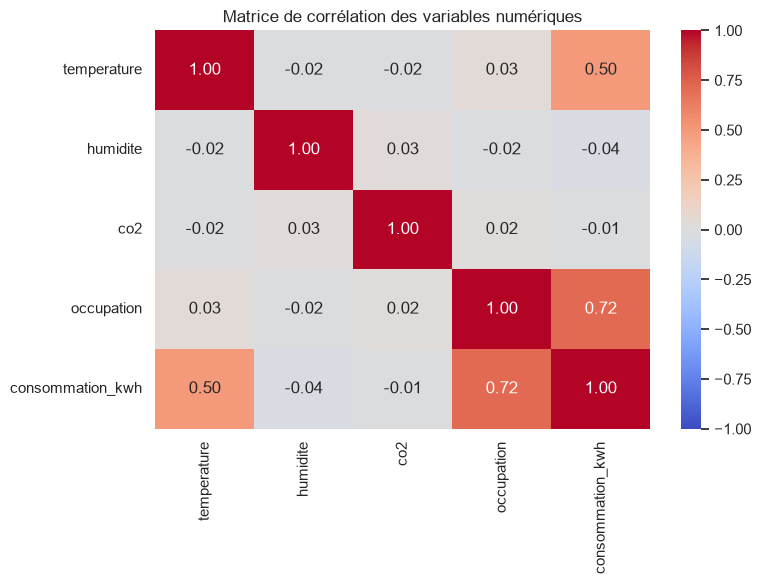

,temperature,humidite,co2,occupation,consommation_kwh
temperature,1.000000,-0.015463,-0.022913,0.031489,0.499415
humidite,-0.015463,1.000000,0.028554,-0.020589,-0.036326
co2,-0.022913,0.028554,1.000000,0.017836,-0.009514
occupation,0.031489,-0.020589,0.017836,1.000000,0.718195
consommation_kwh,0.499415,-0.036326,-0.009514,0.718195,1.000000


In [32]:
corr = df_clean[variables_numeriques_utiles].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Matrice de corrélation des variables numériques")
plt.tight_layout()
plt.show()

corr

**a) Visualisation** : matrice de corrélation ci-dessus (heatmap seaborn).

**b) Identifier les corrélations positives, négatives et les variables faiblement corrélées**
(à commenter avec les valeurs obtenues dans la cellule ci-dessus — le code ci-dessous
identifie automatiquement les paires les plus / moins corrélées pour guider la lecture) :

In [33]:
corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack().sort_values(ascending=False)
print("Corrélations les plus positives :")
print(corr_pairs.head(3))
print()
print("Corrélations les plus négatives :")
print(corr_pairs.tail(3))
print()
print("Corrélations les plus faibles (proches de 0, en valeur absolue) :")
print(corr_pairs.abs().sort_values().head(3))

Corrélations les plus positives :
occupation   consommation_kwh    0.718195
temperature  consommation_kwh    0.499415
             occupation          0.031489
dtype: float64

Corrélations les plus négatives :
consommation_kwh  co2                NaN
                  occupation         NaN
                  consommation_kwh   NaN
dtype: float64

Corrélations les plus faibles (proches de 0, en valeur absolue) :
co2          consommation_kwh    0.009514
temperature  humidite            0.015463
co2          occupation          0.017836
dtype: float64


- Les paires de variables avec une corrélation positive marquée évoluent dans le même
  sens (ex : plus l'occupation augmente, plus la consommation énergétique et le CO₂ ont
  tendance à augmenter — logique physiquement : plus de personnes = plus d'appareils/ventilation
  utilisés et plus de CO₂ émis).
- Une corrélation négative indiquerait que deux variables évoluent en sens opposé.
- Les variables faiblement corrélées (proches de 0) n'ont pas de relation linéaire forte entre
  elles ; cela ne veut pas dire qu'il n'y a aucune relation (elle peut être non-linéaire), mais
  qu'un modèle linéaire n'en tirerait pas beaucoup d'information direct.

---
# Partie 2 – Séparation X / y

### 1) Définir la variable « alerte » comme cible y

In [34]:
y = df_clean["alerte"]
print("Forme de X :", y.shape)


Forme de X : (500,)



2) Trouver des variables explicatives X pertinentes

On exclut de X :

id_mesure : identifiant, sans pouvoir prédictif (fuite potentielle sans information réelle) ;
date : on en extrait des features utiles (déjà capturées en partie par jour_semaine) mais on ne garde pas la date brute, peu exploitable telle quelle par un modèle ;
alerte : c'est la cible, elle ne doit pas apparaître dans X (sinon fuite de données triviale).
Toutes les autres colonnes (numériques et catégorielles) sont des variables explicatives pertinentes pour prédire une alerte ou la consommation énergétique.

In [35]:
colonnes_a_exclure = ["id_mesure", "date", "alerte"]
X = df_clean.drop(columns=colonnes_a_exclure)
print("Forme de X :", X.shape)
X.columns.tolist()

Forme de X : (500, 11)


['batiment',
 'type_batiment',
 'zone',
 'temperature',
 'humidite',
 'co2',
 'occupation',
 'consommation_kwh',
 'mode_climatisation',
 'etat_systeme',
 'jour_semaine']

### 3) Afficher les cinq premières lignes de X ainsi que de y

In [36]:
X.head()

,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine
0,B8,entrepot,A,23.0,40.0,851.0,26.0,138.4,eco,normal,jeudi
1,B7,bureau,D,28.0,69.0,538.0,0.0,170.2,eco,normal,lundi
2,B5,centre commercial,B,19.5,52.3,1198.0,64.0,149.8,normal,normal,dimanche
3,B6,universite,D,20.0,58.4,1014.0,30.0,141.6,normal,normal,dimanche
4,B7,bureau,D,26.8,70.5,628.0,42.0,228.3,normal,normal,jeudi


---
# Partie 3 – Découpage Train/Test

- 20% des données pour le test ;
- reproductibilité garantie via `random_state` ;
- mêmes proportions de classes dans train et test via `stratify=y`.

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train :", X_train.shape, " / X_test :", X_test.shape)
print()
print("Proportions dans y (données d'origine) :")
print(y.value_counts(normalize=True).round(3))
print()
print("Proportions dans y_train :")
print(y_train.value_counts(normalize=True).round(3))
print()
print("Proportions dans y_test :")
print(y_test.value_counts(normalize=True).round(3))

X_train : (400, 11)  / X_test : (100, 11)

Proportions dans y (données d'origine) :
alerte
Non    0.712
Oui    0.288
Name: proportion, dtype: float64

Proportions dans y_train :
alerte
Non    0.712
Oui    0.288
Name: proportion, dtype: float64

Proportions dans y_test :
alerte
Non    0.71
Oui    0.29
Name: proportion, dtype: float64


---
# Partie 4 – Encodage des variables catégorielles

Récapitulatif des variables catégorielles de X et du choix d'encodage :

| Variable              | Cardinalité | Nature                        | Encodage choisi | Justification |
|------------------------|:-----------:|--------------------------------|------------------|----------------|
| `batiment`             | 8           | nominale (aucun ordre)         | One-Hot Encoding | Peu de catégories, pas d'ordre naturel entre bâtiments : le One-Hot évite d'introduire une relation d'ordre artificielle. |
| `type_batiment`        | 6           | nominale                       | One-Hot Encoding | Idem : catégories sans hiérarchie (bureau, hôpital, école...). |
| `zone`                 | 4           | nominale                       | One-Hot Encoding | Peu de modalités, pas d'ordre. |
| `mode_climatisation`   | 3           | **ordinale** (eco < normal < boost) | Ordinal Encoding | Il existe un ordre naturel d'intensité entre les modes, qu'il est pertinent de préserver numériquement. |
| `etat_systeme`         | 3           | nominale                       | One-Hot Encoding | Pas d'ordre logique entre Normal / Alerte / Panne. |
| `jour_semaine`         | 7           | nominale (ou cyclique)         | One-Hot Encoding | Peu de modalités ; un encodage cyclique (sin/cos) serait une alternative avancée mais le One-Hot reste simple et efficace ici. |

Toutes ces variables ont une cardinalité faible (< 10 modalités), ce qui rend le One-Hot
Encoding tout à fait raisonnable (pas d'explosion dimensionnelle). Seule `mode_climatisation`
possède un ordre naturel, justifiant un Ordinal Encoding plutôt qu'un One-Hot.

In [40]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

colonnes_ordinales = ["mode_climatisation"]
ordre_climatisation = [["eco", "normal", "boost"]]

colonnes_onehot = ["batiment", "type_batiment", "zone", "etat_systeme", "jour_semaine"]

# Démonstration sur X_train (l'application définitive se fera dans le pipeline, Partie 6)
demo_ordinal = OrdinalEncoder(categories=ordre_climatisation, handle_unknown="use_encoded_value", unknown_value=-1)
demo_onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

exemple_ordinal = demo_ordinal.fit_transform(X_train[colonnes_ordinales].fillna("normal"))
print("Exemple d'encodage ordinal (mode_climatisation) :")
print(pd.DataFrame(exemple_ordinal, columns=colonnes_ordinales).head())

exemple_onehot = demo_onehot.fit_transform(X_train[["etat_systeme"]].fillna("normal"))
print()
print("Exemple d'encodage One-Hot (etat_systeme) :")
print(pd.DataFrame(exemple_onehot, columns=demo_onehot.get_feature_names_out(["etat_systeme"])).head())

Exemple d'encodage ordinal (mode_climatisation) :
   mode_climatisation
0                 1.0
1                 1.0
2                 2.0
3                 0.0
4                 1.0

Exemple d'encodage One-Hot (etat_systeme) :
   etat_systeme_alerte  etat_systeme_normal  etat_systeme_panne
0                  0.0                  1.0                 0.0
1                  1.0                  0.0                 0.0
2                  0.0                  1.0                 0.0
3                  0.0                  1.0                 0.0
4                  0.0                  1.0                 0.0


---
# Partie 5 – Mise à l'échelle

\### 1) Pertinence de la mise à l'échelle

On compare les échelles de quelques variables numériques :

In [41]:
X_train[["temperature", "humidite", "co2", "consommation_kwh", "occupation"]].describe().loc[["mean","std","min","max"]]

,temperature,humidite,co2,consommation_kwh,occupation
mean,23.800518,57.008073,838.164975,170.468878,45.521739
std,3.291658,12.096141,558.102912,51.221598,24.762956
min,12.300000,21.500000,89.000000,26.400000,0.000000
max,34.200000,89.500000,6000.000000,336.200000,116.000000


On constate que ces variables numériques ont des **échelles très différentes** :
`co2` varie sur plusieurs centaines/milliers d'unités alors que `temperature` ou `humidite`
varient sur quelques dizaines d'unités seulement. De nombreux algorithmes de Machine Learning
(régression logistique, SVM, k-NN, réseaux de neurones, tout algorithme basé sur une distance
ou un gradient) sont sensibles à ces différences d'échelle : une variable avec de grandes
valeurs numériques dominerait artificiellement le calcul (distance, norme, gradient) au
détriment de variables tout aussi informatives mais à plus petite échelle. La mise à l'échelle
est donc indispensable ici.